In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df= pd.read_csv('Pharma_Industry.csv')

# 1) Exploratory Data Analysis (EDA)

In [3]:
df.head()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1


In [4]:
df.shape

(500, 6)

In [5]:
df.describe()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,-0.037761,0.214957,0.062871,0.054398,-0.171863,0.5200
std,0.979891,1.247567,0.971978,0.986001,0.983765,0.5001
min,-3.019512,-3.773897,-2.940389,-3.401277,-3.110431,0.0000
25%,-0.642003,-0.565168,-0.648157,-0.586085,-0.797715,0.0000
50%,-0.019340,0.201532,0.027732,-0.065661,-0.108106,1.0000
75%,0.641151,0.951375,0.710774,0.633914,0.513555,1.0000
max,2.949094,4.111751,3.193108,3.373269,2.518023,1.0000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Drug Dosage (mg)                500 non-null    float64
 1   Systolic Blood Pressure (mmHg)  500 non-null    float64
 2   Heart Rate (BPM)                500 non-null    float64
 3   Liver Toxicity Index (U/L)      500 non-null    float64
 4   Blood Glucose Level (mg/dL)     500 non-null    float64
 5   Drug Response                   500 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 23.6 KB


In [7]:
df.isnull().sum()

Drug Dosage (mg)                  0
Systolic Blood Pressure (mmHg)    0
Heart Rate (BPM)                  0
Liver Toxicity Index (U/L)        0
Blood Glucose Level (mg/dL)       0
Drug Response                     0
dtype: int64

In [8]:
df.columns

Index(['Drug Dosage (mg)', 'Systolic Blood Pressure (mmHg)',
       'Heart Rate (BPM)', 'Liver Toxicity Index (U/L)',
       'Blood Glucose Level (mg/dL)', 'Drug Response'],
      dtype='object')

In [9]:
df_numeric= df._get_numeric_data()

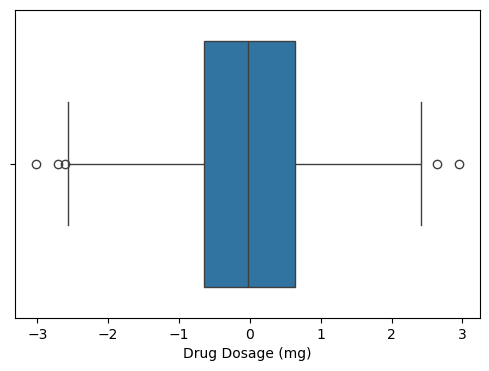

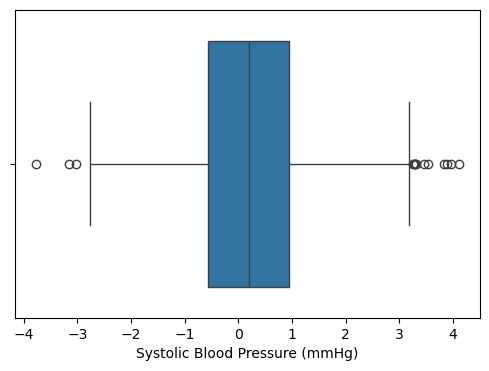

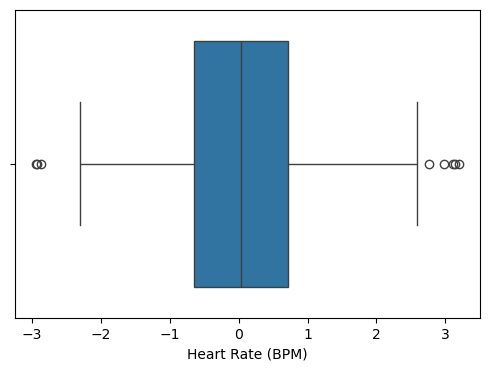

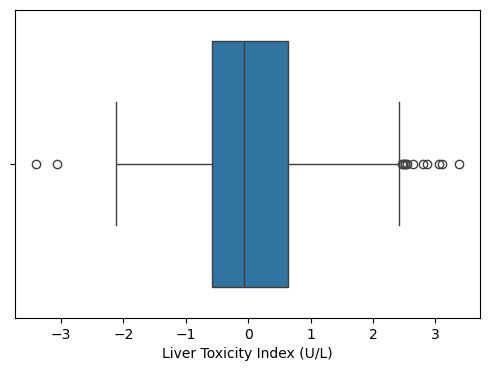

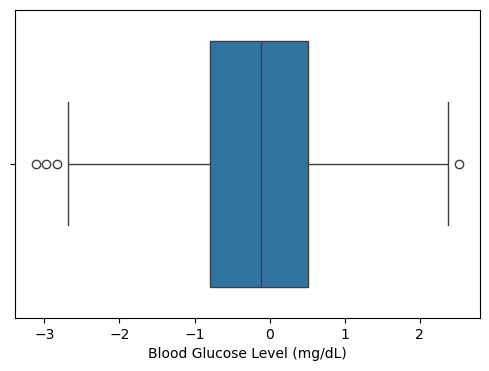

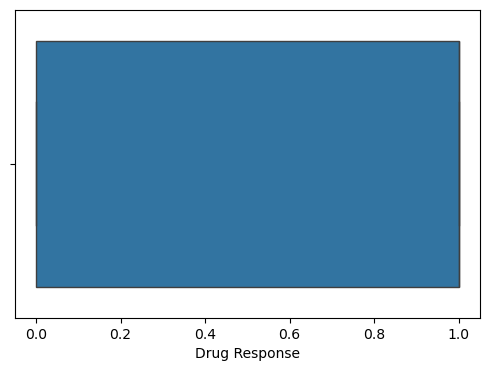

In [10]:
col=['Drug Dosage (mg)', 'Systolic Blood Pressure (mmHg)',
       'Heart Rate (BPM)', 'Liver Toxicity Index (U/L)',
       'Blood Glucose Level (mg/dL)', 'Drug Response']
for i in col :
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df_numeric[i])

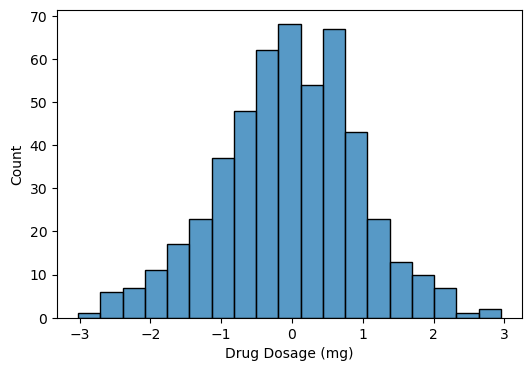

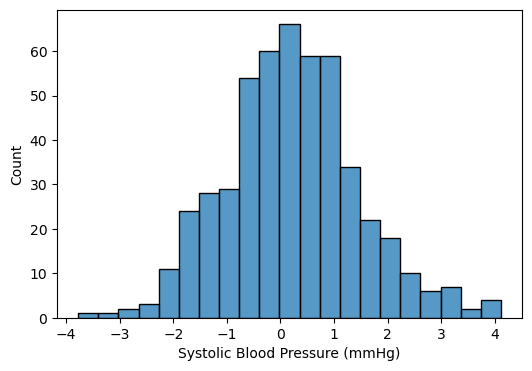

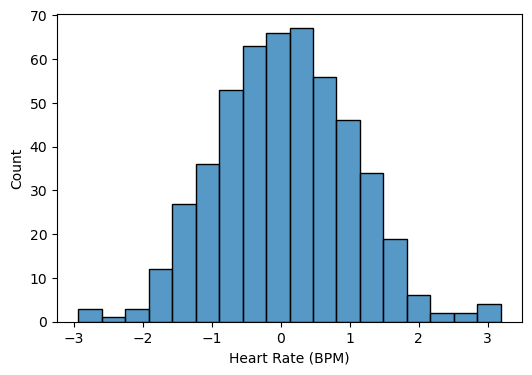

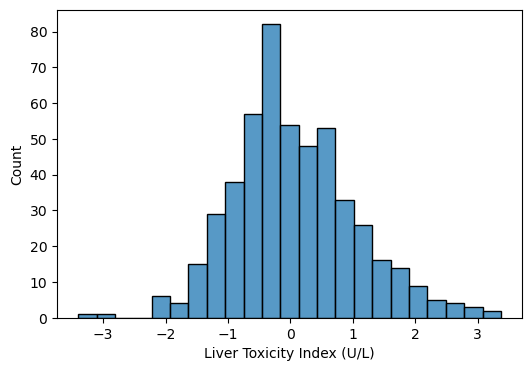

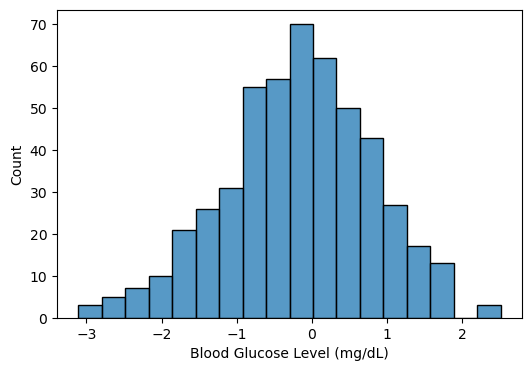

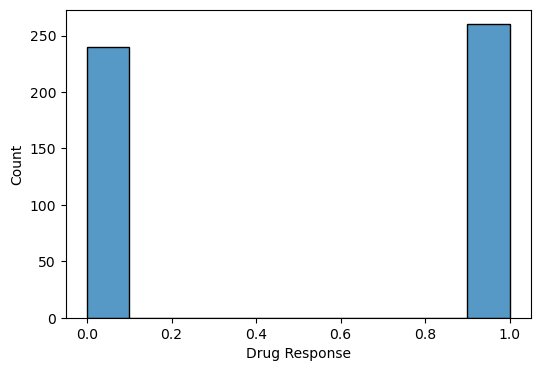

In [11]:
col=['Drug Dosage (mg)', 'Systolic Blood Pressure (mmHg)',
       'Heart Rate (BPM)', 'Liver Toxicity Index (U/L)',
       'Blood Glucose Level (mg/dL)', 'Drug Response']
for i in col :
    plt.figure(figsize=(6,4))
    sns.histplot(x=df_numeric[i])

<Axes: >

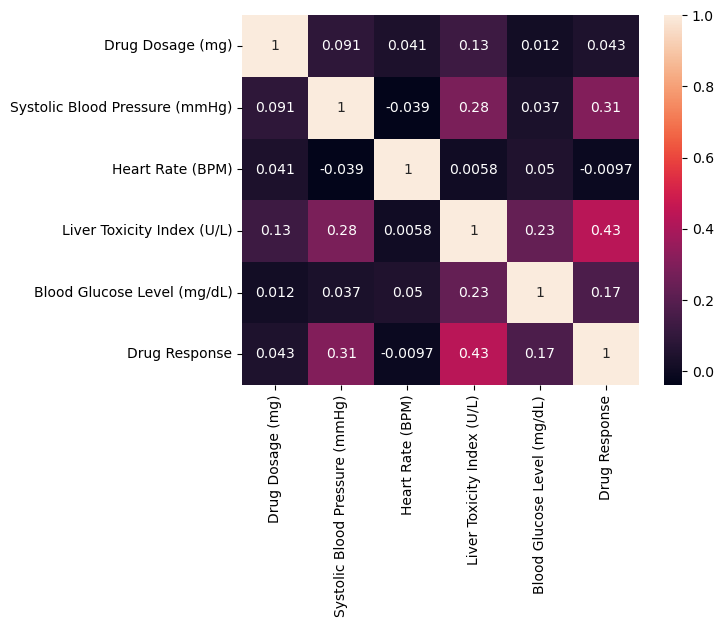

In [12]:
sns.heatmap(df.corr(numeric_only=True), annot= True)

In [13]:
# there are no categorical dat to encode..

In [14]:
x= df.drop('Drug Response',axis=1)

In [15]:
y=df['Drug Response']

# 2)  Data Preprocessing 

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [19]:
df.columns

Index(['Drug Dosage (mg)', 'Systolic Blood Pressure (mmHg)',
       'Heart Rate (BPM)', 'Liver Toxicity Index (U/L)',
       'Blood Glucose Level (mg/dL)', 'Drug Response'],
      dtype='object')

# 3)  Data Visualization

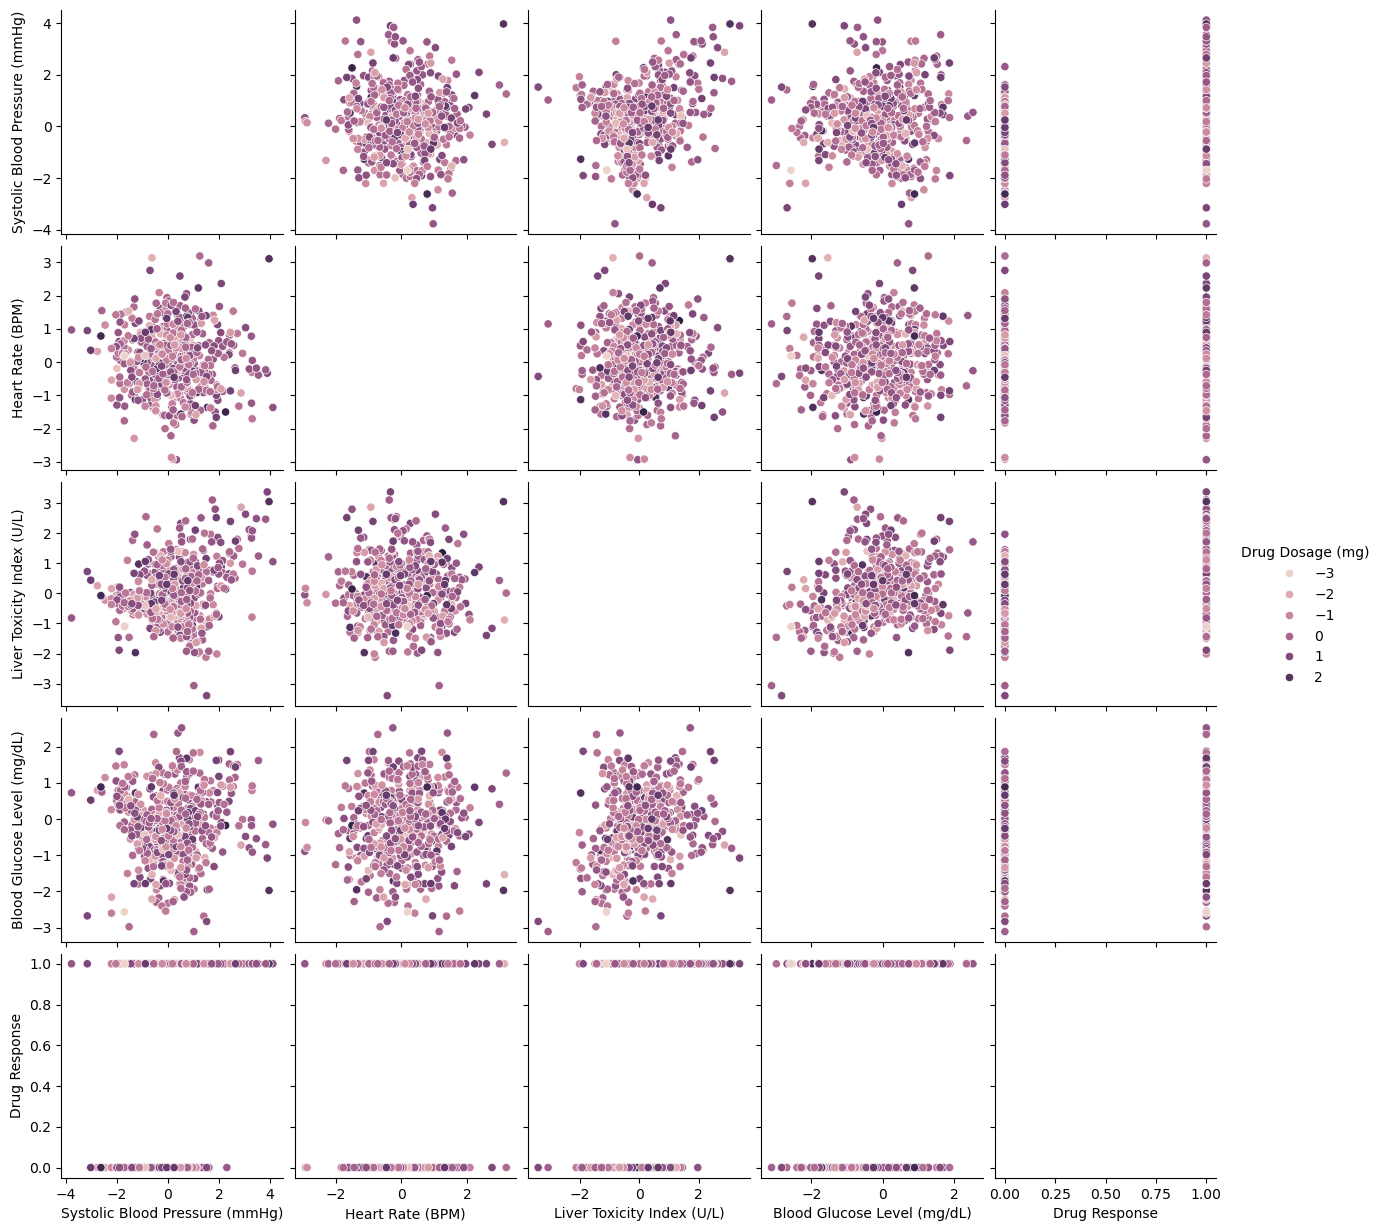

In [20]:
sns.pairplot(df,hue='Drug Dosage (mg)')

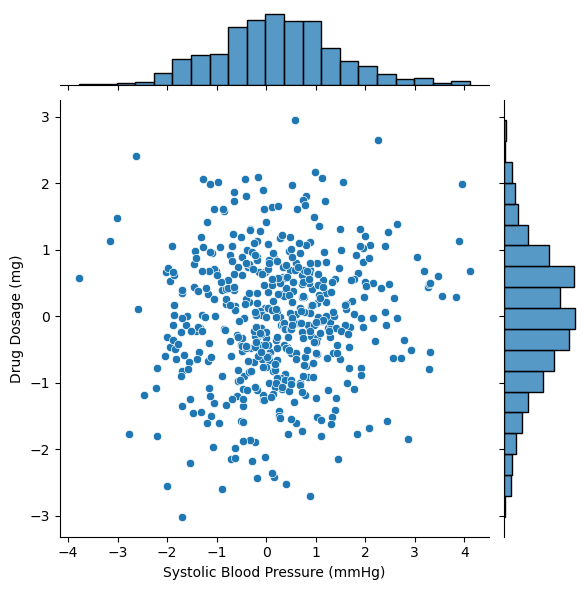

In [21]:
sns.jointplot(x='Systolic Blood Pressure (mmHg)',y='Drug Dosage (mg)',data =df,kind= 'scatter')

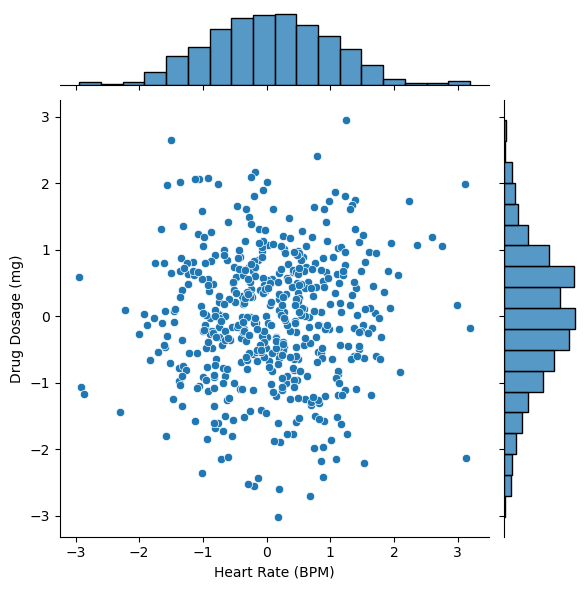

In [22]:
sns.jointplot(x='Heart Rate (BPM)',y='Drug Dosage (mg)',data =df,kind= 'scatter')

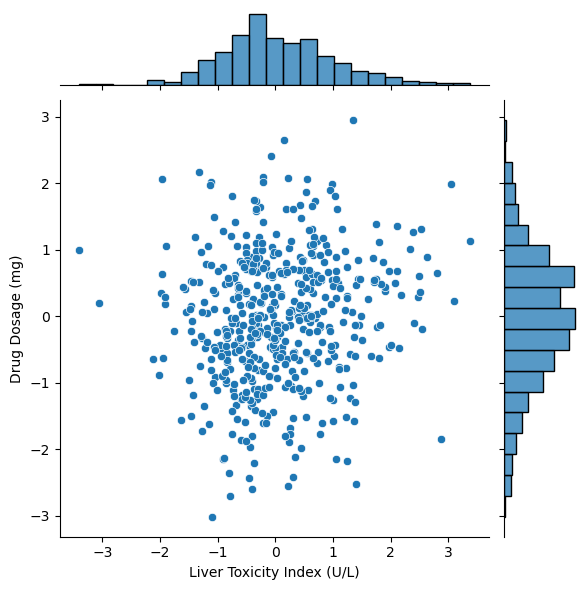

In [23]:
sns.jointplot(x='Liver Toxicity Index (U/L)',y='Drug Dosage (mg)',data =df,kind= 'scatter')

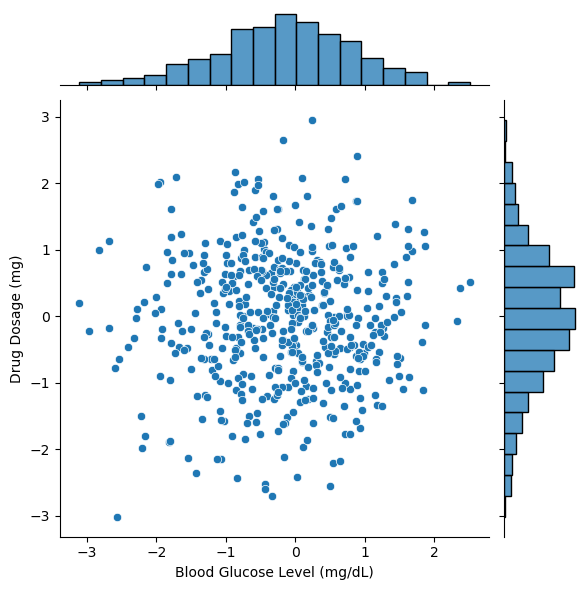

In [24]:
sns.jointplot(x= 'Blood Glucose Level (mg/dL)',y='Drug Dosage (mg)',data =df,kind= 'scatter')

# 4) SVM Implementation 

In [35]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,confusion_matrix, classification_report

In [27]:
model_svm = SVC(kernel='rbf')
model_svm.fit(x_train,y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [33]:
y_pred = model_svm.predict(x_test)

In [34]:
accuracy_score(y_pred,y_test)

0.82

In [36]:
confusion_matrix(y_test,y_pred)

array([[37,  7],
       [11, 45]])

In [37]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.77      0.84      0.80        44
           1       0.87      0.80      0.83        56

    accuracy                           0.82       100
   macro avg       0.82      0.82      0.82       100
weighted avg       0.82      0.82      0.82       100



# 5)  visul

In [38]:
from sklearn.decomposition import PCA
pca = PCA(n_components=3)
X_pca_3d = pca.fit_transform(x_train)

In [39]:
svm_linear_3d = SVC(kernel='rbf', C=1.0)
svm_linear_3d.fit(X_pca_3d, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


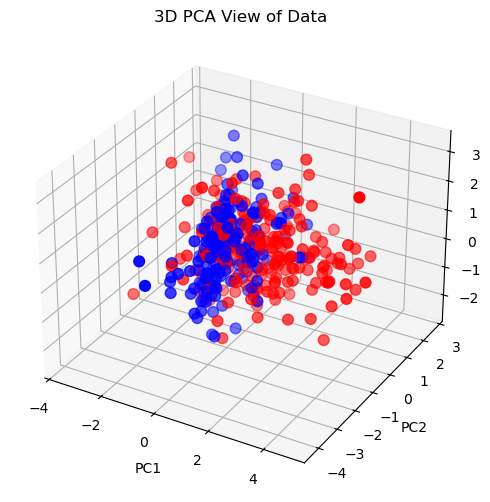

In [41]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    X_pca_3d[:, 0],
    X_pca_3d[:, 1],
    X_pca_3d[:, 2],
    c=y_train,
    cmap='bwr',
    s=60
)


ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D PCA View of Data")
plt.show()

# 6) Parameter Tuning and Optimization 

## linear kernel 

In [53]:
model_svmlinear = SVC(kernel='linear',C=1.0)
model_svmlinear.fit(x_train,y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [55]:
y_pred = model_svmlinear.predict(x_test)
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[36  8]
 [14 42]]
              precision    recall  f1-score   support

           0       0.72      0.82      0.77        44
           1       0.84      0.75      0.79        56

    accuracy                           0.78       100
   macro avg       0.78      0.78      0.78       100
weighted avg       0.79      0.78      0.78       100



## poly kernel

In [49]:
model_svmpoly = SVC(kernel='poly',degree=3,C=1.0)
model_svmpoly.fit(x_train,y_train)

,C,1.0
,kernel,'poly'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [56]:
y_pred = model_svmpoly.predict(x_test)
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[39  5]
 [26 30]]
              precision    recall  f1-score   support

           0       0.60      0.89      0.72        44
           1       0.86      0.54      0.66        56

    accuracy                           0.69       100
   macro avg       0.73      0.71      0.69       100
weighted avg       0.74      0.69      0.68       100



## rbf kernel

In [51]:
model_svmrbf = SVC(kernel='rbf',gamma=0.5,C=1.0)
model_svmrbf.fit(x_train,y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,0.5
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [57]:
y_pred = model_svmrbf.predict(x_test)
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[33 11]
 [12 44]]
              precision    recall  f1-score   support

           0       0.73      0.75      0.74        44
           1       0.80      0.79      0.79        56

    accuracy                           0.77       100
   macro avg       0.77      0.77      0.77       100
weighted avg       0.77      0.77      0.77       100



# 7)Comparison and Analysis

#### The RBF kernel accuracy is 77 % 
#### The poly kernel accuracy is 69%
#### The linear kernel accuracy is 78%
## We can say that linear kernel will give us the good model